# Bootstrap and Jackknife

<a target="_blank" href="https://colab.research.google.com/github/JunyoungB/statistical-computing/blob/main/ch6.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Bootstrap

R0 = 0.7764, se_boot = 0.1472


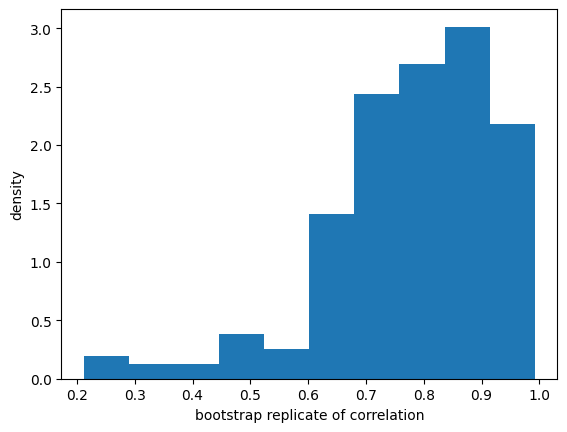

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# data
lsat = np.array([576, 635, 558, 578, 666, 580, 555, 661, 651, 605,
                 653, 575, 545, 572, 594], dtype=float)
gpa  = np.array([339, 330, 281, 303, 344, 307, 300, 343, 336, 313,
                 312, 274, 276, 288, 296], dtype=float)

def corr(x, y):
    return np.corrcoef(x, y)[0, 1]

# theta hat
R0 = corr(lsat, gpa)

# bootstrap
B = 200
n = len(lsat)

R = np.empty(B)
for b in range(B):
    i = np.random.choice(n, size=n)      # sample indices with replacement
    R[b] = corr(lsat[i], gpa[i])

print("R0 = %.4f, se_boot = %.4f"%(R0, R.std(ddof=1)))

# histogram of bootstrap replicates
plt.hist(R, density=True, bins=10)
plt.xlabel("bootstrap replicate of correlation")
plt.ylabel("density")
#plt.savefig("figs/6-1.png", dpi=160, bbox_inches="tight")
plt.show()

### Bootstrap Estimate of Standard Error

In [6]:
# sample estimate
theta_hat = corr(lsat, gpa)

# bootstrap estimate of bias
B = 2000
n = len(lsat)

theta_b = np.empty(B)
for b in range(B):
    i = np.random.choice(n, size=n)  
    theta_b[b] = corr(lsat[i], gpa[i])

bias_hat = theta_b.mean() - theta_hat
se_hat   = theta_b.std(ddof=1)
cv       = bias_hat / se_hat
print(bias_hat, se_hat, cv)

-0.005772070953989905 0.13242264300484216 -0.043588247621510194


## Jackknife

### Jackknife Estimate of Bias

In [7]:
# patch data columns
y = np.array([-1200, 2601, -2705, 1982, -1290, 351, -638, -2719], dtype=float)
z = np.array([ 8406, 2342,  8187, 8459,  4795, 3516,  4796, 10238], dtype=float)

n = len(y)
theta_hat = y.mean() / z.mean()

# jackknife replicates
theta_jack = np.empty(n)
for i in range(n):
    theta_jack[i] = np.delete(y, i).mean() / np.delete(z, i).mean()

bias_jack = (n - 1) * (theta_jack.mean() - theta_hat)
print(bias_jack)

0.008002488358107449


### Jackknife Estimate of Standard Error

In [8]:
y = np.array([-1200, 2601, -2705, 1982, -1290, 351, -638, -2719], dtype=float)
z = np.array([ 8406, 2342,  8187, 8459,  4795, 3516,  4796, 10238], dtype=float)

n = len(y)
theta_hat = y.mean() / z.mean()

theta_jack = np.empty(n)
for i in range(n):
    theta_jack[i] = np.delete(y, i).mean() / np.delete(z, i).mean()

bias_jack = (n - 1) * (theta_jack.mean() - theta_hat)
se_jack   = np.sqrt((n - 1) * np.mean((theta_jack - theta_jack.mean())**2))
cv        = bias_jack / se_jack

print(se_jack, cv)

0.10552778537998952 0.07583299819371461


### Failure Example: Median

In [10]:
x = np.array([29, 79, 41, 86, 91, 5, 50, 83, 51, 42], dtype=float)
n = len(x)

# jackknife estimate of se of the median
M = np.empty(n)
for i in range(n):
    M[i] = np.median(np.delete(x, i))
Mbar = M.mean()
se_jack = np.sqrt((n - 1) / n * np.sum((M - Mbar)**2))
print(se_jack)

# bootstrap estimate of se of the median
B = 1000
Mb = np.empty(B)
for b in range(B):
    y = np.random.choice(x, size=n)
    Mb[b] = np.median(y)
print(Mb.std(ddof=1))

1.5
13.431294005368903


## Bootstrap Confidence Intervals

In [13]:
from scipy.stats import norm

y = np.array([-1200, 2601, -2705, 1982, -1290, 351, -638, -2719], dtype=float)
z = np.array([ 8406, 2342,  8187, 8459,  4795, 3516,  4796, 10238], dtype=float)
B = 1000
n = len(y)
theta_hat = y.mean() / z.mean()

# bootstrap replicates
t = np.empty(B)
for b in range(B):
    i = np.random.choice(n, size=n)
    t[b] = y[i].mean() / z[i].mean()

# bootstrap summaries
bias_hat = t.mean() - theta_hat
se_hat = t.std(ddof=1)

alpha = np.array([0.025, 0.975])

# normal interval (definition-based; bias correction is noted separately in the text)
ci_norm = theta_hat + norm.ppf(alpha) * se_hat
# basic interval
ci_basic = 2 * theta_hat - np.quantile(t, alpha[::-1])  # [0.975, 0.025]
# percentile interval
ci_perc = np.quantile(t, alpha)

print({"t0": theta_hat, "bias": bias_hat, "se": se_hat})
print("normal     :", ci_norm)
print("basic      :", ci_basic)
print("percentile :", ci_perc)

{'t0': np.float64(-0.07130609590256017), 'bias': np.float64(0.009080474634773066), 'se': np.float64(0.10173049727355869)}
normal     : [-0.27069421  0.12808201]
basic      : [-0.30137017  0.08727862]
percentile : [-0.22989081  0.15875798]


## Application: Cross Validation

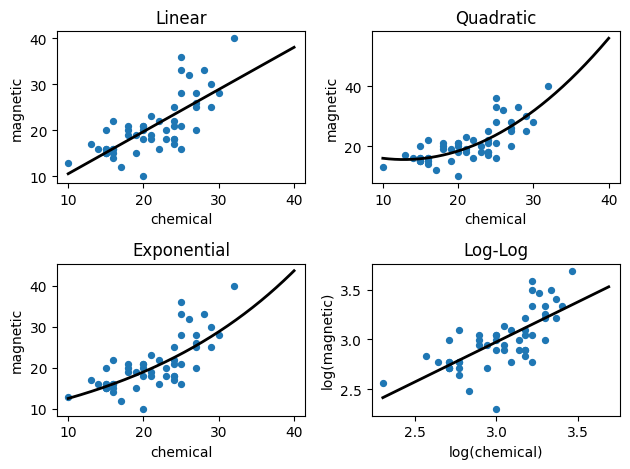

In [16]:
import pandas as pd

X = pd.read_csv("data/chemical.csv").values.flatten()
Y = pd.read_csv("data/magnetic.csv").values.flatten()

a = np.arange(10.0, 40.0 + 1e-12, 0.1)  # sequence for plotting fits
# ---- Model 1: linear Y = b0 + b1 X
b1 = np.polyfit(X, Y, deg=1)            # [b1, b0]
yhat1 = b1[1] + b1[0] * a
# ---- Model 2: quadratic Y = b0 + b1 X + b2 X^2
b2 = np.polyfit(X, Y, deg=2)            # [b2, b1, b0]
yhat2 = b2[2] + b2[1] * a + b2[0] * a**2
# ---- Model 3: exponential log(Y) = c0 + c1 X  =>  Y = exp(c0 + c1 X)
c3 = np.polyfit(X, np.log(Y), deg=1)    # [c1, c0]
yhat3 = np.exp(c3[1] + c3[0] * a)
# ---- Model 4: log-log log(Y) = d0 + d1 log(X)
d4 = np.polyfit(np.log(X), np.log(Y), deg=1)  # [d1, d0]
log_yhat4 = d4[1] + d4[0] * np.log(a)

fig, ax = plt.subplots(2, 2)

ax[0,0].scatter(X, Y, s=18)
ax[0,0].plot(a, yhat1, linewidth=2, color='k')
ax[0,0].set_title("Linear")
ax[0,0].set_xlabel("chemical")
ax[0,0].set_ylabel("magnetic")

ax[0,1].scatter(X, Y, s=18)
ax[0,1].plot(a, yhat2, linewidth=2, color='k')
ax[0,1].set_title("Quadratic")
ax[0,1].set_xlabel("chemical")
ax[0,1].set_ylabel("magnetic")

ax[1,0].scatter(X, Y, s=18)
ax[1,0].plot(a, yhat3, linewidth=2, color='k')
ax[1,0].set_title("Exponential")
ax[1,0].set_xlabel("chemical")
ax[1,0].set_ylabel("magnetic")

ax[1,1].scatter(np.log(X), np.log(Y), s=18)
ax[1,1].plot(np.log(a), log_yhat4, linewidth=2, color='k')
ax[1,1].set_title("Log-Log")
ax[1,1].set_xlabel("log(chemical)")
ax[1,1].set_ylabel("log(magnetic)")

plt.tight_layout()
#plt.savefig("figs/6-2.png", dpi=160, bbox_inches="tight")
plt.show()

### Prediction Error Estimates

In [17]:
n = len(Y)
e1 = np.empty(n)
e2 = np.empty(n)
e3 = np.empty(n)
e4 = np.empty(n)

for k in range(n):
    x_tr = np.delete(X, k)
    y_tr = np.delete(Y, k)

    b1 = np.polyfit(x_tr, y_tr, deg=1)          # Model 1: linear
    yhat1 = b1[1] + b1[0] * X[k]
    e1[k] = Y[k] - yhat1
    
    b2 = np.polyfit(x_tr, y_tr, deg=2)          # Model 2: quadratic
    yhat2 = b2[2] + b2[1] * X[k] + b2[0] * X[k]**2
    e2[k] = Y[k] - yhat2
    
    c3 = np.polyfit(x_tr, np.log(y_tr), deg=1)  # Model 3: exponential (fit log(Y) on X)
    yhat3 = np.exp(c3[1] + c3[0] * X[k])
    e3[k] = Y[k] - yhat3
    
    d4 = np.polyfit(np.log(x_tr), np.log(y_tr), deg=1)  # Model 4: log-log (fit log(Y) on log(X))
    yhat4 = np.exp(d4[1] + d4[0] * np.log(X[k]))
    e4[k] = Y[k] - yhat4

mse = np.array([np.mean(e1**2), np.mean(e2**2), np.mean(e3**2), np.mean(e4**2)])
print(mse)

[19.55644438 17.85247506 18.44187853 20.45424213]
